In [1]:
import numpy as np
import pandas as pd
#import seaborn as sns
import plotly.express as px
from matplotlib import pyplot as plt
from sklearn.model_selection import cross_val_score

from sklearn import metrics
from collections import Counter

In [2]:
from sklearn.calibration import calibration_curve
import xgboost as xgb
import lightgbm as lgb
import os, time, warnings
warnings.filterwarnings('ignore')
from sklearn.base import clone

plt.rcParams.update({'figure.figsize': (14, 6), 'figure.dpi': 100, 'font.size': 11})
COLOR_RETAINED = '#2ecc71'
COLOR_CHURNED = '#e74c3c'
print("Libraries loaded.")

Libraries loaded.


In [3]:
df = pd.read_csv(r'E:\Users\Avishka\JobData\MyProjects\ml-model\data\Telco-Customer-Churn.csv')


In [4]:
column_list = df.columns.tolist()
print(column_list)

['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [48]:
df.shape

(7043, 24)

In [5]:
df.duplicated().any()

False

In [6]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [7]:
df['TotalCharges'].isnull().sum()

0

In [8]:
df.drop('customerID', axis=1, inplace=True)

In [9]:
df['Churn'] = df['Churn'].map({'Yes':1, 'No':0})

In [10]:
# binary_cols = ['Partner','Dependents','PhoneService','PaperlessBilling','OnlineSecurity','OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']

# for col in binary_cols:
#     df[col] = df[col].map({'Yes':1, 'No':0})

In [11]:
for col in [ 'gender','InternetService','Contract', 'PaymentMethod', 'MultipleLines']:
    print(f"Unique values in '{col}':")
    print(df[col].unique())
    print()

Unique values in 'gender':
['Female' 'Male']

Unique values in 'InternetService':
['DSL' 'Fiber optic' 'No']

Unique values in 'Contract':
['Month-to-month' 'One year' 'Two year']

Unique values in 'PaymentMethod':
['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']

Unique values in 'MultipleLines':
['No phone service' 'No' 'Yes']



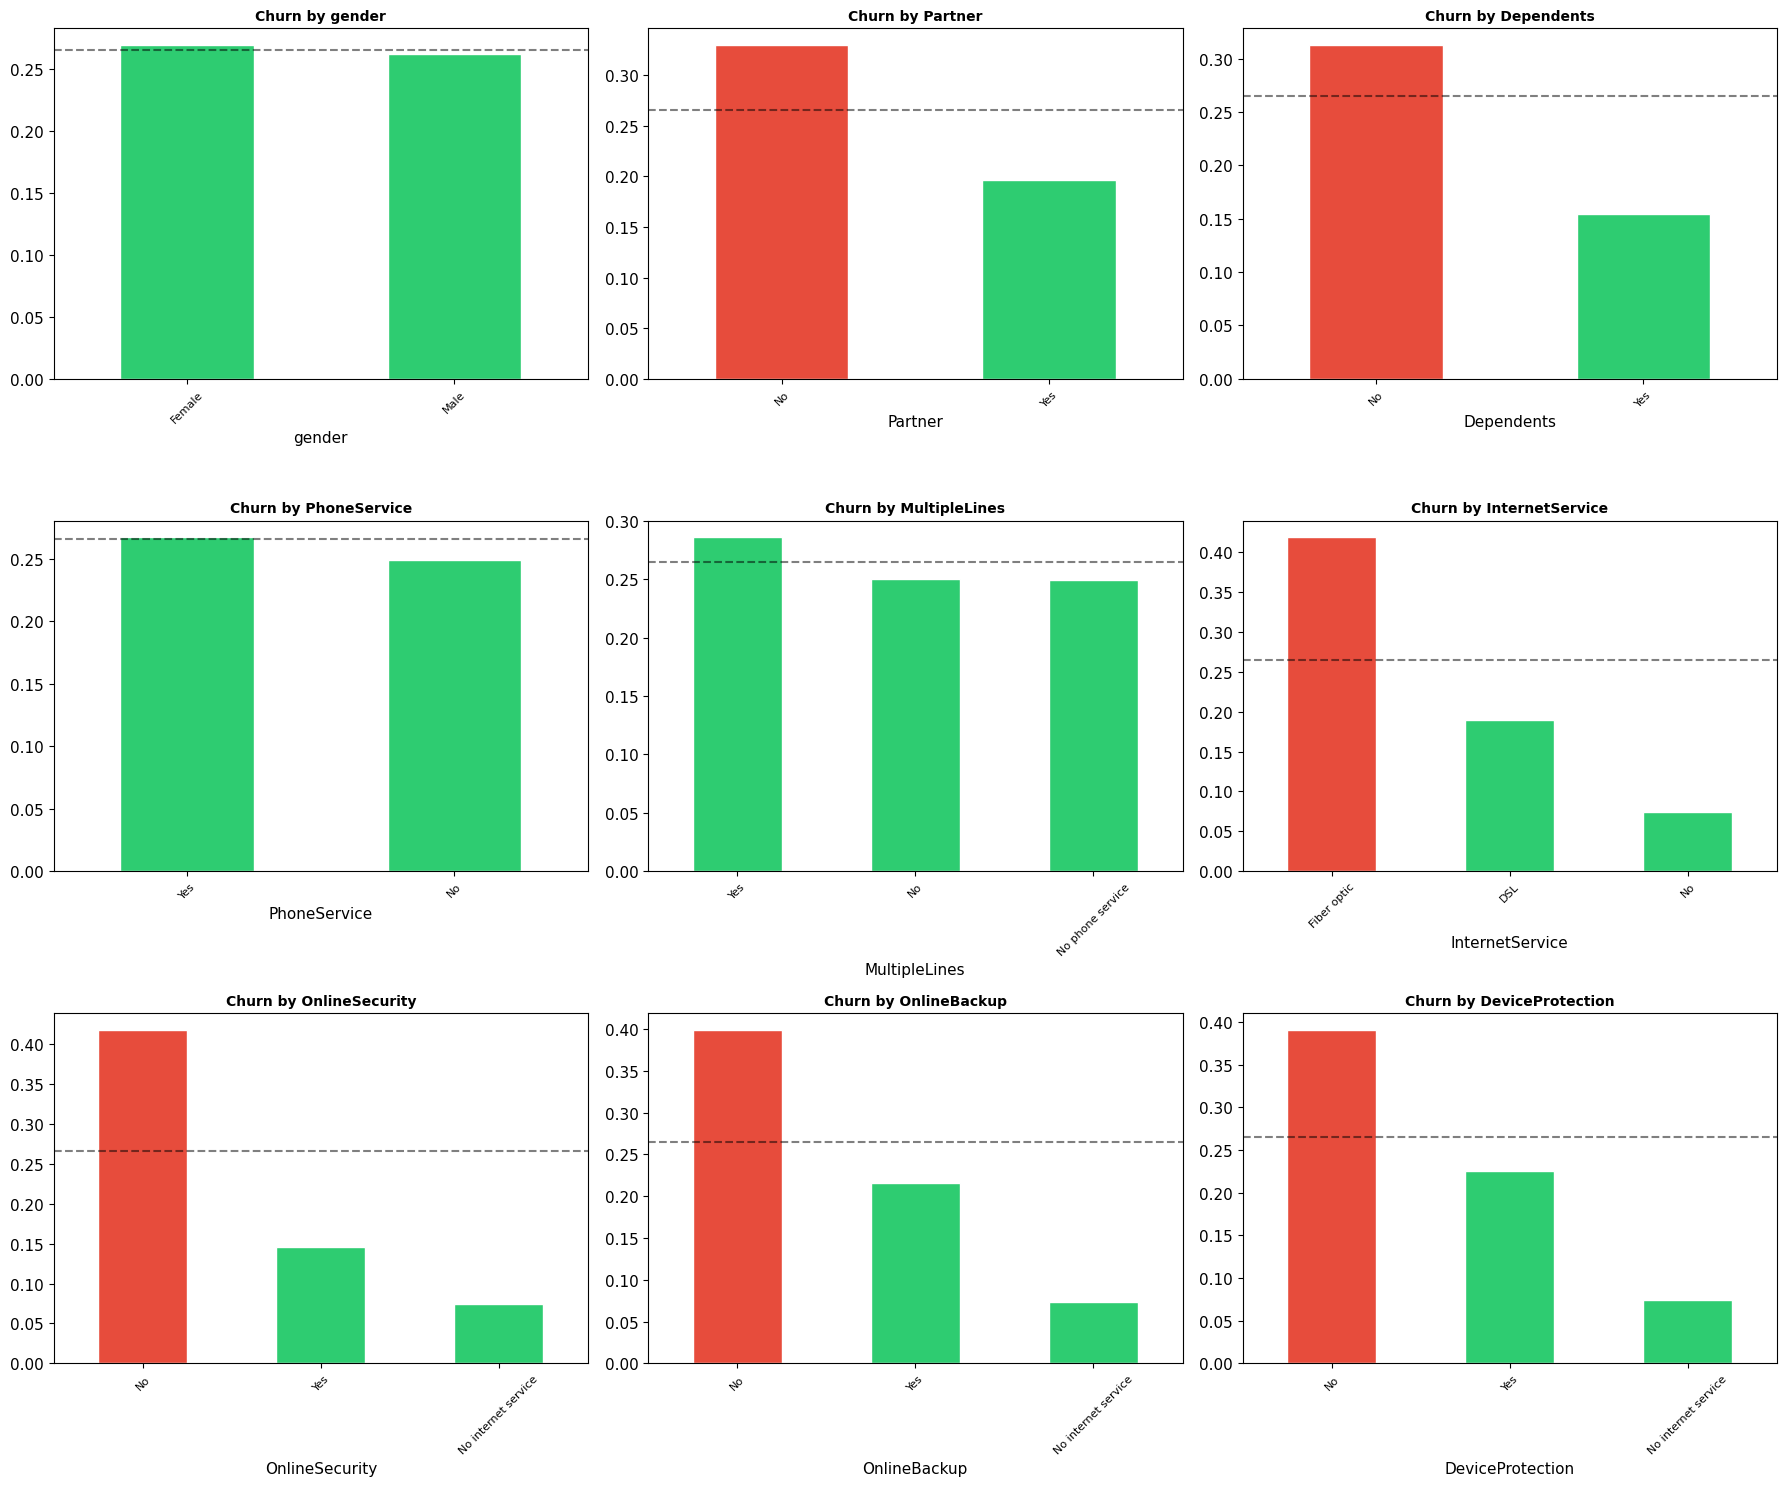

In [12]:
import matplotlib.pyplot as plt
import numpy as np

# Define target info
target_col = 'Churn'
minority_class = 1
churn_pct = df[target_col].mean() * 100  # overall churn percentage

# 2.2 Categorical features — churn rate
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
cat_cols = [c for c in cat_cols if c != target_col and df[c].nunique() <= 10]

n_cats = min(len(cat_cols), 9)
if n_cats > 0:
    rows = (n_cats + 2) // 3
    fig, axes = plt.subplots(rows, 3, figsize=(18, 5 * rows))
    axes = np.array(axes).flatten()
    
    for idx, col in enumerate(cat_cols[:n_cats]):
        ax = axes[idx]
        # Churn rate per category
        cr = df.groupby(col)[target_col].apply(lambda x: (x == minority_class).mean()).sort_values(ascending=False)
        colors = [COLOR_CHURNED if r > churn_pct/100*1.1 else COLOR_RETAINED for r in cr.values]
        cr.plot(kind='bar', ax=ax, color=colors, edgecolor='white')
        ax.set_title(f'Churn by {col}', fontweight='bold', fontsize=10)
        ax.axhline(y=churn_pct/100, color='black', linestyle='--', alpha=0.5)
        ax.tick_params(axis='x', rotation=45, labelsize=8)
    
    # Hide extra axes
    for idx in range(n_cats, len(axes)):
        axes[idx].set_visible(False)
    plt.tight_layout()
    plt.show()

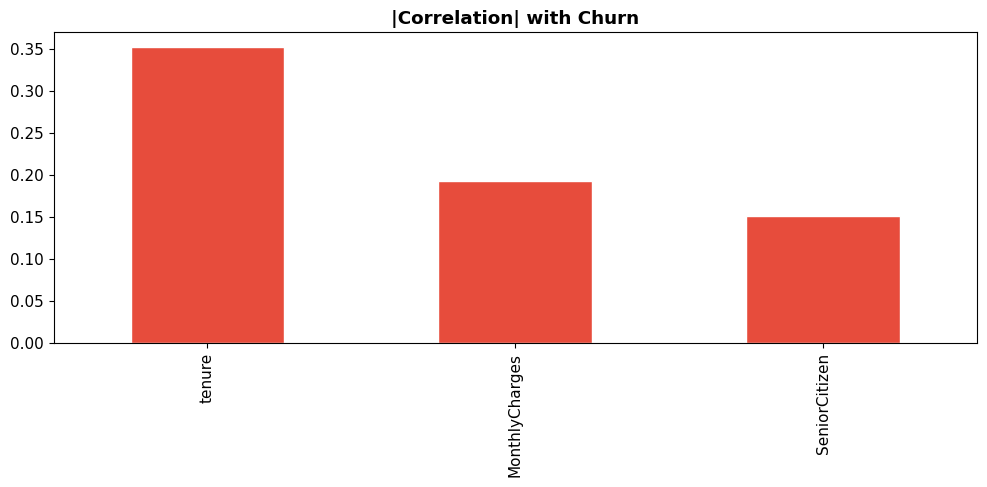

In [13]:
# Correlation

num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c != target_col]

target_binary = (df[target_col] == minority_class).astype(int)
if num_cols:
    corr = df[num_cols].corrwith(target_binary).abs().sort_values(ascending=False)
    fig, ax = plt.subplots(figsize=(10, 5))
    corr.plot(kind='bar', ax=ax, color=[COLOR_CHURNED if c > 0.1 else '#95a5a6' for c in corr.values], edgecolor='white')
    ax.set_title('|Correlation| with Churn', fontweight='bold')
    plt.tight_layout()
    plt.show()

In [14]:
df.replace({
    'No phone service': 'No',
    'No internet service': 'No'
}, inplace=True)

In [15]:
binary_cols = ['Partner','Dependents','PhoneService','PaperlessBilling','OnlineSecurity','OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'MultipleLines']

for col in binary_cols:
    df[col] = df[col].map({'Yes':1, 'No':0})

In [16]:
df['gender'] = df['gender'].map({
    'Female': 0,
    'Male': 1
})

In [17]:
df = pd.get_dummies(df, columns=['InternetService'], drop_first=True)

In [18]:
contract_map = {
    'Month-to-month': 0,
    'One year': 1,
    'Two year': 2
}

df['Contract'] = df['Contract'].map(contract_map)

In [19]:
df = pd.get_dummies(df, columns=['PaymentMethod'])

In [20]:
df.head(10)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,InternetService_Fiber optic,InternetService_No,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,0,0,1,0,...,1,29.85,29.85,0,False,False,False,False,True,False
1,1,0,0,0,34,1,0,1,0,1,...,0,56.95,1889.5,0,False,False,False,False,False,True
2,1,0,0,0,2,1,0,1,1,0,...,1,53.85,108.15,1,False,False,False,False,False,True
3,1,0,0,0,45,0,0,1,0,1,...,0,42.30,1840.75,0,False,False,True,False,False,False
4,0,0,0,0,2,1,0,0,0,0,...,1,70.70,151.65,1,True,False,False,False,True,False
5,0,0,0,0,8,1,1,0,0,1,...,1,99.65,820.5,1,True,False,False,False,True,False
6,1,0,0,1,22,1,1,0,1,0,...,1,89.10,1949.4,0,True,False,False,True,False,False
7,0,0,0,0,10,0,0,1,0,0,...,0,29.75,301.9,0,False,False,False,False,False,True
8,0,0,1,0,28,1,1,0,0,1,...,1,104.80,3046.05,1,True,False,False,False,True,False
9,1,0,0,1,62,1,0,1,1,0,...,0,56.15,3487.95,0,False,False,True,False,False,False


In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 24 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   gender                                   7043 non-null   int64  
 1   SeniorCitizen                            7043 non-null   int64  
 2   Partner                                  7043 non-null   int64  
 3   Dependents                               7043 non-null   int64  
 4   tenure                                   7043 non-null   int64  
 5   PhoneService                             7043 non-null   int64  
 6   MultipleLines                            7043 non-null   int64  
 7   OnlineSecurity                           7043 non-null   int64  
 8   OnlineBackup                             7043 non-null   int64  
 9   DeviceProtection                         7043 non-null   int64  
 10  TechSupport                              7043 no

In [22]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [23]:
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

In [24]:
bool_cols = df.select_dtypes(include=['bool']).columns
df[bool_cols] = df[bool_cols].astype(int)

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 24 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   gender                                   7043 non-null   int64  
 1   SeniorCitizen                            7043 non-null   int64  
 2   Partner                                  7043 non-null   int64  
 3   Dependents                               7043 non-null   int64  
 4   tenure                                   7043 non-null   int64  
 5   PhoneService                             7043 non-null   int64  
 6   MultipleLines                            7043 non-null   int64  
 7   OnlineSecurity                           7043 non-null   int64  
 8   OnlineBackup                             7043 non-null   int64  
 9   DeviceProtection                         7043 non-null   int64  
 10  TechSupport                              7043 no

In [26]:
df.describe()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,InternetService_Fiber optic,InternetService_No,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,...,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.504756,0.162147,0.483033,0.299588,32.371149,0.903166,0.421837,0.286668,0.344881,0.343888,...,0.592219,64.761692,2281.916928,0.265370,0.439585,0.216669,0.219225,0.216101,0.335794,0.228880
std,0.500013,0.368612,0.499748,0.458110,24.559481,0.295752,0.493888,0.452237,0.475363,0.475038,...,0.491457,30.090047,2265.270398,0.441561,0.496372,0.412004,0.413751,0.411613,0.472301,0.420141
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,18.250000,18.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,9.000000,1.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,35.500000,402.225000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1.000000,0.000000,0.000000,0.000000,29.000000,1.000000,0.000000,0.000000,0.000000,0.000000,...,1.000000,70.350000,1397.475000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,1.000000,0.000000,1.000000,1.000000,55.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,89.850000,3786.600000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000,72.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,118.750000,8684.800000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [27]:
import plotly.express as px


counts = df['Churn'].value_counts()


counts = counts.reindex([0, 1])

fig = px.pie(
    values=counts.values,
    names=counts.index,
    width=700,
    height=400,
    color_discrete_sequence=["skyblue", "black"],
    title="Churn vs Non-Churn Distribution"
)

fig.show()

In [28]:
df_feat = df.copy()


# Service count
service_cols = [
    'PhoneService','MultipleLines','OnlineSecurity','OnlineBackup',
    'DeviceProtection','TechSupport','StreamingTV','StreamingMovies'
]
df_feat['n_services'] = df_feat[service_cols].sum(axis=1)

# Charge per tenure
df_feat['charge_tenure_ratio'] = df_feat['MonthlyCharges'] / df_feat['tenure'].clip(lower=1)

# Charge consistency
df_feat['charge_consistency'] = df_feat['TotalCharges'] / (df_feat['MonthlyCharges'] * df_feat['tenure'].clip(lower=1))

# Tenure features
df_feat['tenure_log'] = np.log1p(df_feat['tenure'])
df_feat['is_new_user'] = (df_feat['tenure'] <= 6).astype(int)
df_feat['is_long_term'] = (df_feat['tenure'] >= 48).astype(int)

# Log charges
df_feat['MonthlyCharges_log'] = np.log1p(df_feat['MonthlyCharges'])
df_feat['TotalCharges_log'] = np.log1p(df_feat['TotalCharges'])

# AvgCharges & LongTermCustomer
df_feat['AvgCharges'] = df_feat['TotalCharges'] / df_feat['tenure'].clip(lower=1)
df_feat['LongTermCustomer'] = (df_feat['tenure'] > 24).astype(int)

# Show new features
new_features = [c for c in df_feat.columns if c not in df.columns]
print("Engineered features:", new_features)

Engineered features: ['n_services', 'charge_tenure_ratio', 'charge_consistency', 'tenure_log', 'is_new_user', 'is_long_term', 'MonthlyCharges_log', 'TotalCharges_log', 'AvgCharges', 'LongTermCustomer']


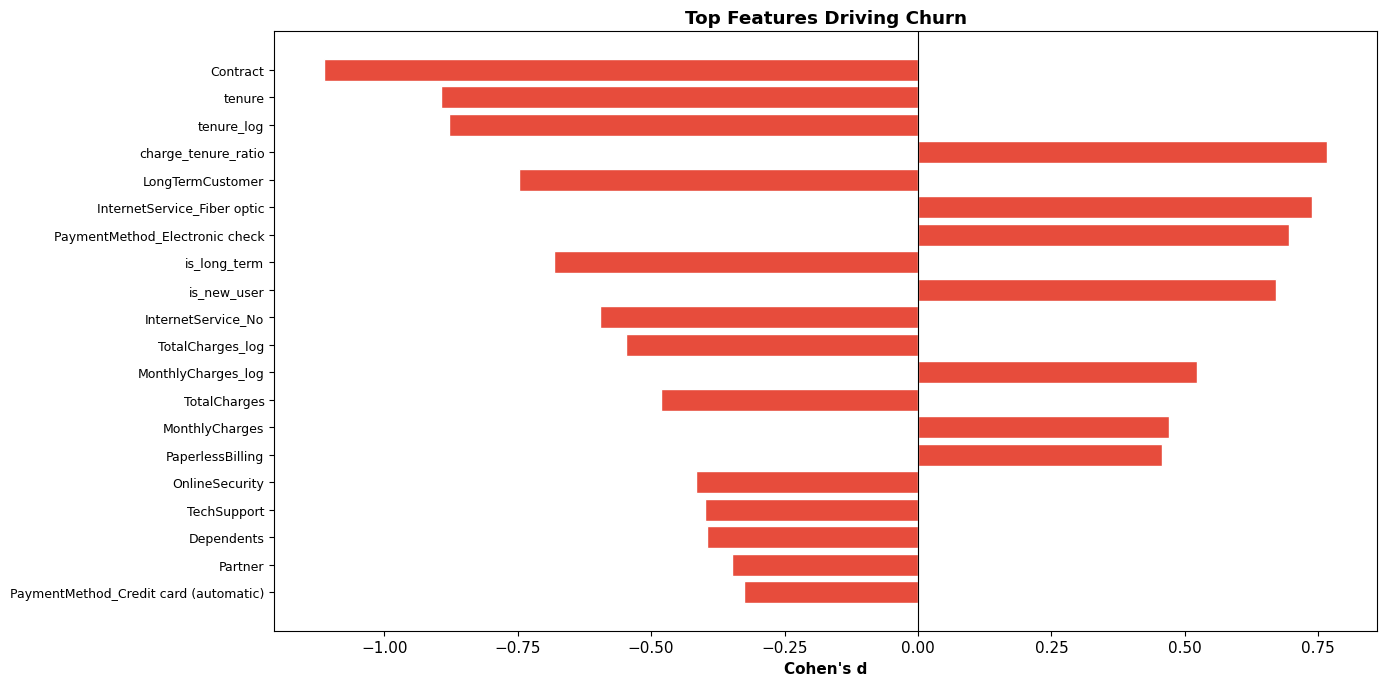

Top disengagement drivers:
  Contract                       d=-1.112
  tenure                         d=-0.893
  tenure_log                     d=-0.879
  charge_tenure_ratio            d=+0.766
  LongTermCustomer               d=-0.747
  InternetService_Fiber optic    d=+0.739
  PaymentMethod_Electronic check d=+0.695
  is_long_term                   d=-0.682


In [29]:
import numpy as np
import matplotlib.pyplot as plt

# Colors
COLOR_CHURNED = '#e74c3c'
COLOR_RETAINED = '#2ecc71'

# Target and features
target_col = 'Churn'
feature_cols = [c for c in df_feat.columns if c != target_col]

# Data arrays
X = df_feat[feature_cols].values
y = df_feat[target_col].values

# Cohen's d calculation
cohens_d = {}
for i, col in enumerate(feature_cols):
    ok = X[y==0, i]  # retained
    ch = X[y==1, i]  # churned
    ps = np.sqrt((ok.std()**2 + ch.std()**2)/2)  # pooled std
    cohens_d[col] = (ch.mean() - ok.mean()) / ps if ps > 0 else 0

# Sort by absolute effect
sorted_effects = sorted(cohens_d.items(), key=lambda x: abs(x[1]), reverse=True)

# Plot top 20 features
fig, ax = plt.subplots(figsize=(14, max(6, min(20, len(sorted_effects))*0.35)))
feats = [x[0] for x in sorted_effects[:20]]
vals = [x[1] for x in sorted_effects[:20]]
colors = [COLOR_CHURNED if abs(d)>0.3 else COLOR_RETAINED if abs(d)>0.15 else '#bdc3c7' for d in vals]

ax.barh(range(len(feats)), vals, color=colors, edgecolor='white')
ax.set_yticks(range(len(feats)))
ax.set_yticklabels(feats, fontsize=9)
ax.set_xlabel("Cohen's d", fontweight='bold')
ax.set_title("Top Features Driving Churn", fontweight='bold')
ax.axvline(x=0, color='black', linewidth=0.8)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Print top 8 features
print("Top disengagement drivers:")
for f, d in sorted_effects[:8]:
    print(f"  {f:30s} d={d:+.3f}")

In [30]:
# # Correlation

# num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
# num_cols = [c for c in num_cols if c != target_col]

# target_binary = (df[target_col] == minority_class).astype(int)
# if num_cols:
#     corr = df[num_cols].corrwith(target_binary).abs().sort_values(ascending=False)
#     fig, ax = plt.subplots(figsize=(10, 5))
#     corr.plot(kind='bar', ax=ax, color=[COLOR_CHURNED if c > 0.1 else '#95a5a6' for c in corr.values], edgecolor='white')
#     ax.set_title('|Correlation| with Churn', fontweight='bold')
#     plt.tight_layout()
#     plt.show()

In [31]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,InternetService_Fiber optic,InternetService_No,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,0,0,1,0,...,1,29.85,29.85,0,0,0,0,0,1,0
1,1,0,0,0,34,1,0,1,0,1,...,0,56.95,1889.50,0,0,0,0,0,0,1
2,1,0,0,0,2,1,0,1,1,0,...,1,53.85,108.15,1,0,0,0,0,0,1
3,1,0,0,0,45,0,0,1,0,1,...,0,42.30,1840.75,0,0,0,1,0,0,0
4,0,0,0,0,2,1,0,0,0,0,...,1,70.70,151.65,1,1,0,0,0,1,0


In [32]:
df_feat.head(10)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,n_services,charge_tenure_ratio,charge_consistency,tenure_log,is_new_user,is_long_term,MonthlyCharges_log,TotalCharges_log,AvgCharges,LongTermCustomer
0,0,0,1,0,1,0,0,0,1,0,...,1,29.850000,1.000000,0.693147,1,0,3.429137,3.429137,29.850000,0
1,1,0,0,0,34,1,0,1,0,1,...,3,1.675000,0.975830,3.555348,0,0,4.059581,7.544597,55.573529,1
2,1,0,0,0,2,1,0,1,1,0,...,3,26.925000,1.004178,1.098612,1,0,4.004602,4.692723,54.075000,0
3,1,0,0,0,45,0,0,1,0,1,...,3,0.940000,0.967034,3.828641,0,0,3.768153,7.518471,40.905556,1
4,0,0,0,0,2,1,0,0,0,0,...,1,35.350000,1.072489,1.098612,1,0,4.272491,5.028148,75.825000,0
5,0,0,0,0,8,1,1,0,0,1,...,5,12.456250,1.029227,2.197225,0,0,4.611649,6.711132,102.562500,0
6,1,0,0,1,22,1,1,0,1,0,...,4,4.050000,0.994490,3.135494,0,0,4.500920,7.575790,88.609091,0
7,0,0,0,0,10,0,0,1,0,0,...,1,2.975000,1.014790,2.397895,0,0,3.425890,5.713403,30.190000,0
8,0,0,1,0,28,1,1,0,0,1,...,6,3.742857,1.038049,3.367296,0,0,4.661551,8.021929,108.787500,1
9,1,0,0,1,62,1,0,1,1,0,...,3,0.905645,1.001910,4.143135,0,1,4.045679,8.157356,56.257258,1


In [44]:
df.duplicated().any()

True

In [46]:
# Count of duplicate rows
duplicate_count = df_feat.duplicated().sum()
print(duplicate_count)

22


In [47]:
drop_duplicates = df_feat.drop_duplicates()
print(drop_duplicates.shape)

(7021, 34)


In [33]:
#df_feat.to_csv(r'E:\Users\Avishka\JobData\MyProjects\ml-model\data\Processed-Telco-Customer-Churn.csv', index=False)
